# Import Library

In [ ]:
# ==============================
# 📊 Library Manipulasi Data
# ==============================
import numpy as np  # Library dasar untuk komputasi numerik (array, matriks, dll)
import pandas as pd  # Library untuk analisis dan manipulasi data berbasis tabel (DataFrame)

# ==============================
# 📈 Library Visualisasi
# ==============================
import matplotlib.pyplot as plt  # Untuk membuat visualisasi grafik (plot, chart, dll)
from mpl_toolkits.axes_grid1 import ImageGrid  # Untuk menampilkan beberapa gambar dalam satu grid
import seaborn as sns  # Untuk visualisasi statistik yang lebih menarik dan informatif

# ==============================
# 🖥️ Library Sistem & File
# ==============================
import kagglehub  # Untuk mengakses dan mengunduh dataset dari Kaggle
import os  # Untuk berinteraksi dengan sistem operasi (file, folder, path, dll)
import time  # Untuk mengatur atau menghitung waktu proses
from google.colab import files  # Untuk upload dan download file di Google Colab

# ==============================
# 🤖 Library Machine Learning (Scikit-learn)
# ==============================
from sklearn.model_selection import train_test_split  # Membagi data menjadi train dan test
from sklearn.metrics import accuracy_score  # Menghitung akurasi model klasifikasi
from sklearn.metrics import classification_report  # Menampilkan laporan evaluasi (precision, recall, f1-score)
from sklearn.metrics import confusion_matrix  # Membuat confusion matrix untuk evaluasi model
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.utils import to_categorical

# ==============================
# 🧠 Deep Learning Framework
# ==============================
import tensorflow as tf  # Library utama untuk deep learning dan komputasi numerik
import keras  # API high-level untuk membangun model deep learning (bagian dari TensorFlow)

# ==============================
# 🖼️ Preprocessing Citra
# ==============================
# Untuk membuat generator data gambar dengan augmentasi secara real-time
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# Utility tambahan untuk preprocessing gambar
from tensorflow.keras.preprocessing import image
# Untuk memuat gambar ke format PIL (Python Imaging Library)
from tensorflow.keras.preprocessing.image import load_img
# Mengubah gambar (PIL) menjadi array NumPy
from tensorflow.keras.preprocessing.image import img_to_array
# Fungsi preprocessing khusus untuk model EfficientNetV2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input # Ganti
import cv2 # Library OpenCV untuk pengolahan citra (image processing)
from PIL import Image # Library untuk membuka, memanipulasi, dan menyimpan gambar

# ==============================
# 🏗️ Arsitektur Model (Pretrained CNN)
# ==============================
from tensorflow.keras.applications import EfficientNetV2L # Ganti
from keras.callbacks import EarlyStopping, ModelCheckpoint
# Model CNN pretrained yang ringan dan efisien
from tensorflow.keras.layers import BatchNormalization
# Layer untuk menstabilkan distribusi data (mean ~0, std ~1)
from tensorflow.keras.layers import Dropout
# Layer untuk mengurangi overfitting dengan mematikan neuron secara acak
from tensorflow.keras.layers import Dense
# Layer fully connected (neural network biasa)
from tensorflow.keras.models import Model
# Untuk membangun model deep learning (menggabungkan layer)
from tensorflow.keras.optimizers import Adamax
# Optimizer (varian Adam) untuk proses training model

# Dataset Retrieval

In [ ]:
# Download latest version
path = kagglehub.dataset_download("obulisainaren/multi-cancer")
print("Path to dataset files:", path)

# Inspect the contents of the downloaded dataset to find the correct subdirectories
print("Contents of downloaded path:", os.listdir(path))

# Correcting the paths based on the output 'ECG_DATA'
parent_dir = os.path.join(path, "Multi Cancer")

# Once train_dir is correctly defined, you can then uncomment this:
print("Contents of parent_dir:", os.listdir(parent_dir))

# The following lines were previously problematic and should be uncommented/corrected once train_dir is fixed.
all_benign_cases_path = os.path.join(parent_dir, "Multi Cancer/ALL/all_benign")
all_early_cases_path = os.path.join(parent_dir, "Multi Cancer/ALL/all_early")
all_pre_cases_path = os.path.join(parent_dir, "Multi Cancer/ALL/all_pre")
all_pro_cases_path = os.path.join(parent_dir, "Multi Cancer/ALL/all_pro")

print("\nNumber of Training images in all cases")
print(f"All Benign cases: {len(os.listdir(all_benign_cases_path))} images")
print(f"All Early cases: {len(os.listdir(all_early_cases_path))} images")
print(f"All Pre cases: {len(os.listdir(all_pre_cases_path))} images")
print(f"All Pro cases: {len(os.listdir(all_pro_cases_path))} images")

total_images = len(os.listdir(all_benign_cases_path)) + \
               len(os.listdir(all_early_cases_path)) + \
               len(os.listdir(all_pre_cases_path)) + \
               len(os.listdir(all_pro_cases_path))
print(f"\nTotal training images: {total_images} images")

100%|██████████| 8.62G/8.62G [01:22<00:00, 112MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3
Contents of downloaded path: ['README.md', 'Multi Cancer']
Contents of parent_dir: ['Multi Cancer']

Number of Training images in all cases
All Benign cases: 5000 images
All Early cases: 5000 images
All Pre cases: 5000 images
All Pro cases: 5000 images

Total training images: 20000 images


# Data Preparation

In [ ]:
# Inisialisasi path dan list
filepaths = []
labels = []

# List of image directory paths and their corresponding labels
# These paths were already correctly identified in cell BYudhPuh-wuQ
# We need to explicitly define the mapping of path to its corresponding label
all_image_paths = [
  (all_benign_cases_path, "all_benign"),
  (all_early_cases_path, "all_early"),
  (all_pre_cases_path, "all_pre"),
  (all_pro_cases_path, "all_pro")
]

# Loop through each class image directory and its corresponding label
for img_dir_path, class_name in all_image_paths:
  if os.path.isdir(img_dir_path):
    # List all files in the current image directory
    for filename in os.listdir(img_dir_path):
      # Construct the full path to the image file
      fpath = os.path.join(img_dir_path, filename);
      # Ensure it's a file and has a common image extension
      if os.path.isfile(fpath) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        filepaths.append(fpath)
        labels.append(class_name) # Assign the correct class label

# Konversi ke pandas series
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')

# Gabungkan jadi DataFrame
df = pd.concat([Fseries, Lseries], axis=1)

display(df)

,filepaths,labels
0,/root/.cache/kagglehub/datasets/obulisainaren/...,all_benign
1,/root/.cache/kagglehub/datasets/obulisainaren/...,all_benign
2,/root/.cache/kagglehub/datasets/obulisainaren/...,all_benign
3,/root/.cache/kagglehub/datasets/obulisainaren/...,all_benign
4,/root/.cache/kagglehub/datasets/obulisainaren/...,all_benign
...,...,...
19995,/root/.cache/kagglehub/datasets/obulisainaren/...,all_pro
19996,/root/.cache/kagglehub/datasets/obulisainaren/...,all_pro
19997,/root/.cache/kagglehub/datasets/obulisainaren/...,all_pro
19998,/root/.cache/kagglehub/datasets/obulisainaren/...,all_pro


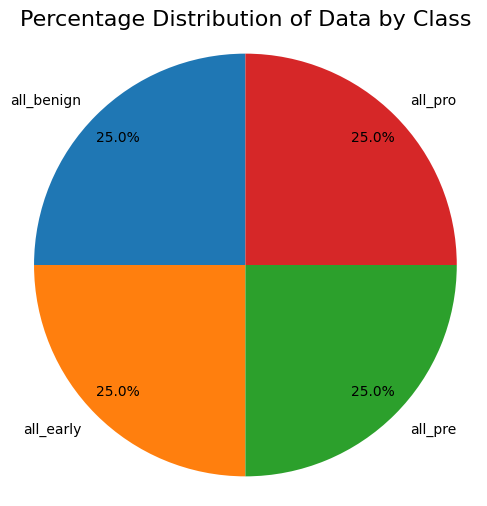

In [ ]:
# Menampilkan distribusi jumlah data tiap kelas dalam bentuk pie chart (diagram lingkaran)
class_counts = df['labels'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Percentage Distribution of Data by Class', fontsize=16)
plt.axis('equal')
plt.show()

# Data Preprocessing

In [ ]:
# Pembagian: 70% Latih, 30% Sisa (untuk Val + Tes)
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['labels'], random_state=42)
# Pembagian Sisa (30%) menjadi dua: 15% Val dan 15% Test
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=42)
# Parameter ini memastikan bahwa proporsi kelas sama seperti pada data asli.
print("Train df shape:", train_df.shape)
print("Test df shape:", test_df.shape)
print("Val df shape:", val_df.shape)

Train df shape: (14000, 2)
Test df shape: (3000, 2)
Val df shape: (3000, 2)


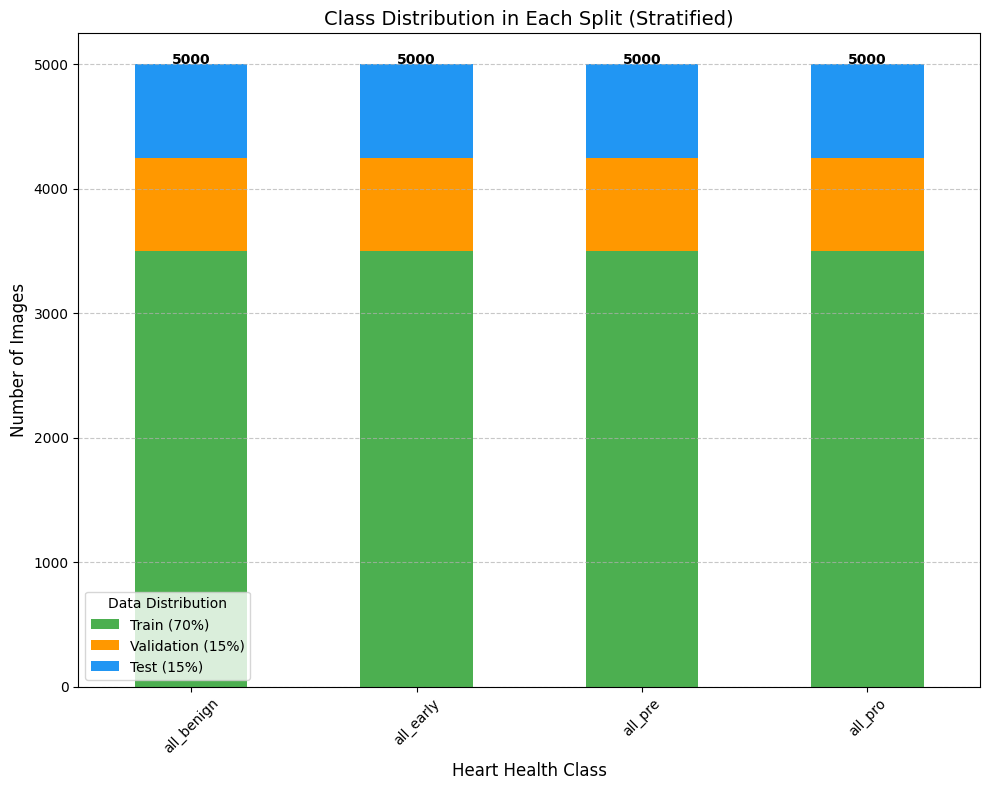

In [ ]:
# Hitung jumlah data per kelas di setiap split
train_counts = train_df['labels'].value_counts().sort_index()
val_counts = val_df['labels'].value_counts().sort_index()
test_counts = test_df['labels'].value_counts().sort_index()

# Siapkan Data untuk Plotting
df_plot = pd.DataFrame({
  "Train (70%)": train_counts,
  "Validation (15%)": val_counts,
  "Test (15%)": test_counts,
})

# Membuat Diagram Batang
plt.figure(figsize=(10, 8)) # Adjusted figure size for a taller chart
ax = df_plot.plot(kind='bar', stacked=True, color=['#4CAF50', '#FF9800', '#2196F3'], ax=plt.gca())
plt.title("Class Distribution in Each Split (Stratified)", fontsize=14)
plt.xlabel("Heart Health Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.legend(title="Data Distribution")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Tambahkan label angka di atas setiap batang
for i, total in enumerate(df_plot.sum(axis=1)):
  ax.text(i, total + 5, int(total), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Menampilkan jumlah data per kelas untuk setiap split (Train, Validation, Test)
df_total = df_plot.copy()
df_total["Total"] = df_plot.sum(axis=1)
display(df_total)

,Train (70%),Validation (15%),Test (15%),Total
labels,,,,
all_benign,3500,750,750,5000
all_early,3500,750,750,5000
all_pre,3500,750,750,5000
all_pro,3500,750,750,5000


# Data Generator

In [ ]:
# Hyperparameter yang menentukan jumlah data yang diproses dalam satu iterasi
batch_size = 128
# Ukuran gambar yang akan digunakan (harus sesuai dengan input model)
target_size = (224, 224)

# Function to check if a file is a valid image
def is_valid_image(filepath):
  try:
    # Attempt to open the image to verify its validity
    with Image.open(filepath) as img:
        img.verify() # Verify if it's a valid image
    return True
  except Exception:
    return False

# Filter out invalid image file paths from the dataframes
train_df = train_df[train_df['filepaths'].apply(is_valid_image)]
val_df = val_df[val_df['filepaths'].apply(is_valid_image)]
test_df = test_df[test_df['filepaths'].apply(is_valid_image)]

# Membuat generator data untuk training dengan augmentasi (penambahan variasi data)
train_datagen = ImageDataGenerator(
  # Fungsi preprocessing sesuai dengan model yang digunakan
  preprocessing_function=preprocess_input,
  rotation_range=20, # Rotasi gambar secara acak hingga \u00b120 derajat
  width_shift_range=0.05, # Pergeseran gambar secara horizontal
  height_shift_range=0.05, # Pergeseran gambar secara vertikal
  shear_range=0.05, # Transformasi kemiringan untuk membuat variasi sudut pandang
  zoom_range=0.05, # Zoom in/out secara acak hingga 5%
  horizontal_flip=True, # Membalik gambar secara horizontal secara acak
  fill_mode="nearest" # Mengisi piksel kosong hasil transformasi dengan nilai terdekat
)

# Membuat generator data untuk validasi, hanya preprocessing
val_datagen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

# Membuat generator data untuk testing, hanya preprocessing
test_datagen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

# Membuat generator data untuk Training dari dataframe
train_generator = train_datagen.flow_from_dataframe(
  dataframe = train_df, # DataFrame yang berisi path gambar dan label
  x_col = "filepaths", # Kolom yang berisi lokasi file gambar
  y_col = "labels", # Kolom yang berisi label (target/output)
  target_size = target_size, # Mengubah ukuran gambar sesuai input model
  color_mode = 'rgb', # Menggunakan 3 channel warna (RGB)
  class_mode = "categorical", # Digunakan untuk klasifikasi multi-kelas
  batch_size = batch_size, # Jumlah gambar dalam satu batch
  shuffle = True, # Shuffle the data order every epoch
  seed = 42)

# Membuat generator data untuk Testing dari dataframe
validation_generator = val_datagen.flow_from_dataframe(
  dataframe = val_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Tidak diacak agar evaluasi konsisten dan adil
  seed = 42)

# Membuat generator data untuk Testing dari dataframe
test_generator = test_datagen.flow_from_dataframe(
  dataframe = test_df,
  x_col = "filepaths",
  y_col = "labels",
  target_size = target_size,
  color_mode = 'rgb',
  class_mode = "categorical",
  batch_size = batch_size,
  shuffle = False, # Tidak diacak agar hasil evaluasi sesuai urutan asli
  seed = 42)

Found 14000 validated image filenames belonging to 4 classes.
Found 3000 validated image filenames belonging to 4 classes.
Found 3000 validated image filenames belonging to 4 classes.


# Exploratory Data Analysis (EDA)

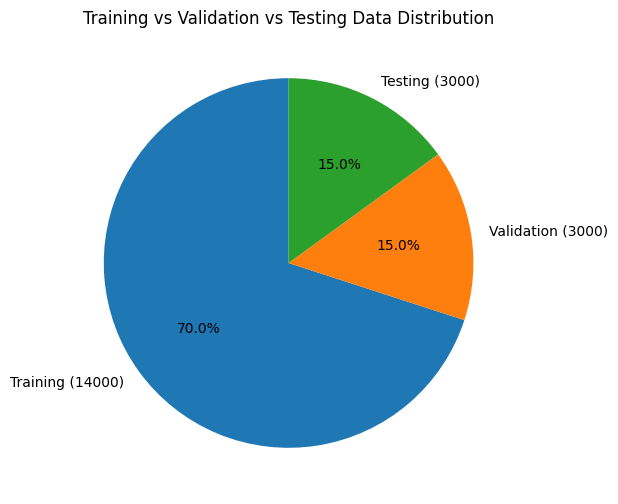

In [ ]:
# Memvisualisasikan proporsi jumlah data pada dataset dalam bentuk pie chart (diagram lingkaran).
counts = [train_generator.samples, validation_generator.samples, test_generator.samples]
labels = [f'Training ({counts[0]})', f'Validation ({counts[1]})', f'Testing ({counts[2]})']
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Training vs Validation vs Testing Data Distribution")
plt.show()

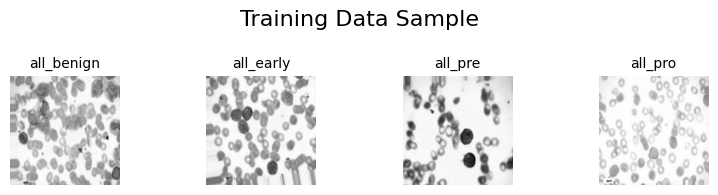

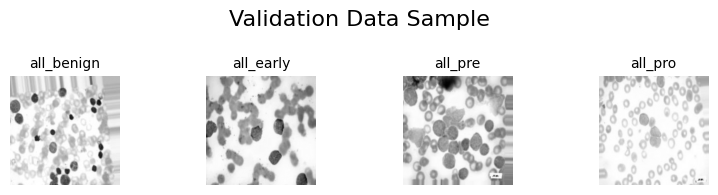

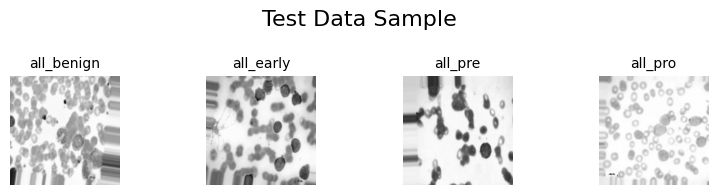

In [ ]:
# Menampilkan beberapa contoh gambar dari setiap kelas (label) pada dataset dalam bentuk grid (tabel gambar)
# Menentukan jumlah gambar per kelas
num_images_per_class = 1

# Mengambil label kelas
class_labels = list(train_generator.class_indices.keys())

# Menyusun dataset yang akan ditampilkan
datasets = [
  (train_df, "Training Data Sample"),
  (val_df, "Validation Data Sample"),
  (test_df, "Test Data Sample")
]

# Loop untuk setiap dataset
for current_df, title in datasets:
  # Membuat canvas gambar dengan orientasi horizontal
  plt.figure(figsize=(len(class_labels) * 2, num_images_per_class * 2)) # Swap width and height
  plt.suptitle(title, fontsize=16)

  # Loop tiap kelas
  for i, label in enumerate(class_labels):
    # Ambil filepath berdasarkan kelas
    class_filepaths = current_df[current_df['labels'] == label]['filepaths'].values

    # Random sampling gambar
    if len(class_filepaths) > 0:
      sampled_filepaths = np.random.choice(class_filepaths, min(num_images_per_class, len(class_filepaths)), replace=False)
    else:
      sampled_filepaths = []

    # Menampilkan gambar
    for j, filepath in enumerate(sampled_filepaths):
      # Posisis subplot (swap rows and columns for horizontal layout)
      plt.subplot(num_images_per_class, len(class_labels), j * len(class_labels) + i + 1)
      # Membaca gambar dalam grayscale dan menampilkan
      img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE) # Read image as grayscale
      plt.imshow(img, cmap='gray') # Display with 'gray' colormap
      # Tambahkan label
      plt.title(f"{label}", fontsize=10)
      plt.axis('off')

  # Rapikan Layout & Tampilkan hasil
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()

# Model Creation (EfficientNetV2L)

In [ ]:
def build_EfficientNetV2L_model():
  # Instantiates the EfficientNetV2L architecture.
  base_model = keras.applications.EfficientNetV2L(
    # Model menggunakan layer klasifikasi terakhir (fully connected layer) EfficientNetV2L.
    include_top=False,
    # Model menggunakan bobot yang sudah dilatih pada dataset ImageNet.
    weights='imagenet',
    # Menggunakan input tensor yang sudah dibuat sebelumnya.
    input_tensor=None,
    # Ukuran standar untuk banyak CNN.
    input_shape=(224, 224, 3),
    # 2 Class pada data penyakit Skin Cancer
    classes = 4,
    # Softmax digunakan untuk multi-class classification
    classifier_activation='softmax',
  )

  # 🔥 Fine-tuning: freeze sebagian layer
  for layer in base_model.layers[:-30]:
    layer.trainable = False

  # Sisakan layer atas tetap trainable
  for layer in base_model.layers[-30:]:
    layer.trainable = True

  # Menyusun arsitektur model
  model = keras.models.Sequential([
    # Feature extractor dari DenseNet
    base_model,
    # Global average pooling operation untuk 2D data.
    keras.layers.GlobalAveragePooling2D(),
    # Fully connected layer untuk pembelajaran pola penyakit
    keras.layers.Dense(256, activation='relu'),
    # Menstabilkan distribusi aktivasi
    keras.layers.BatchNormalization(),
    # Mengurangi overfitting
    keras.layers.Dropout(0.3),
    # Output layer (2 kelas)
    keras.layers.Dense(4, activation='softmax')
  ])

  return model

# Panggil fungsi untuk membuat model
EfficientNetV2L_model = build_EfficientNetV2L_model()
# Tampilkan ringkasan arsitektur model
EfficientNetV2L_model.summary()

473176280/473176280 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-l (Functional)   │ (None, 7, 7, 1280)     │   117,746,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,076,836 (450.43 MB)

 Trainable params: 11,084,356 (42.28 MB)

 Non-trainable params: 106,992,480 (408.14 MB)

# Tuning Hyperparameter 1

In [ ]:
# --- Inisialisasi Parameter ---
# Learning rate mengontrol seberapa besar model mengubah bobotnya setiap kali belajar
learning_rate = 0.01
# Epochs adalah jumlah total pengulangan (iterasi) model mempelajari seluruh dataset
epochs = 20

# --- Konfigurasi Optimizer ---
# Menggunakan Adamax, variasi dari optimizer Adam yang lebih stabil untuk model besar
optimizer = Adamax(learning_rate=learning_rate)

# --- Kompilasi Model ---
# Menyiapkan model sebelum dilatih dengan menentukan :
EfficientNetV2L_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# --- Proses Pelatihan (Training) ---
# Melatih model menggunakan data dari train_generator
# Selama proses ini, model juga akan diuji secara berkala menggunakan validation data
# Hasilnya disimpan di variabel 'history' untuk dianalisis grafiknya nanti
history1 = EfficientNetV2L_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator,
  callbacks=callbacks)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8825 - loss: 0.4043
Epoch 1: val_accuracy improved from None to 0.98300, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 633s 4s/step - accuracy: 0.9452 - loss: 0.1767 - val_accuracy: 0.9830 - val_loss: 0.0430
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9817 - loss: 0.0501
Epoch 2: val_accuracy improved from 0.98300 to 0.99567, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 336s 3s/step - accuracy: 0.9852 - loss: 0.0414 - val_accuracy: 0.9957 - val_loss: 0.0152
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9917 - loss: 0.0245
Epoch 3: val_accuracy did not improve from 0.99567
110/110 ━━━━━━━━━━━━━━━━━━━━ 291s 3s/step - accuracy: 0.9919 - loss: 0.0243 - val_accuracy: 0.9893 - val_loss: 0.0314
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy

# Evaluation Metric 1

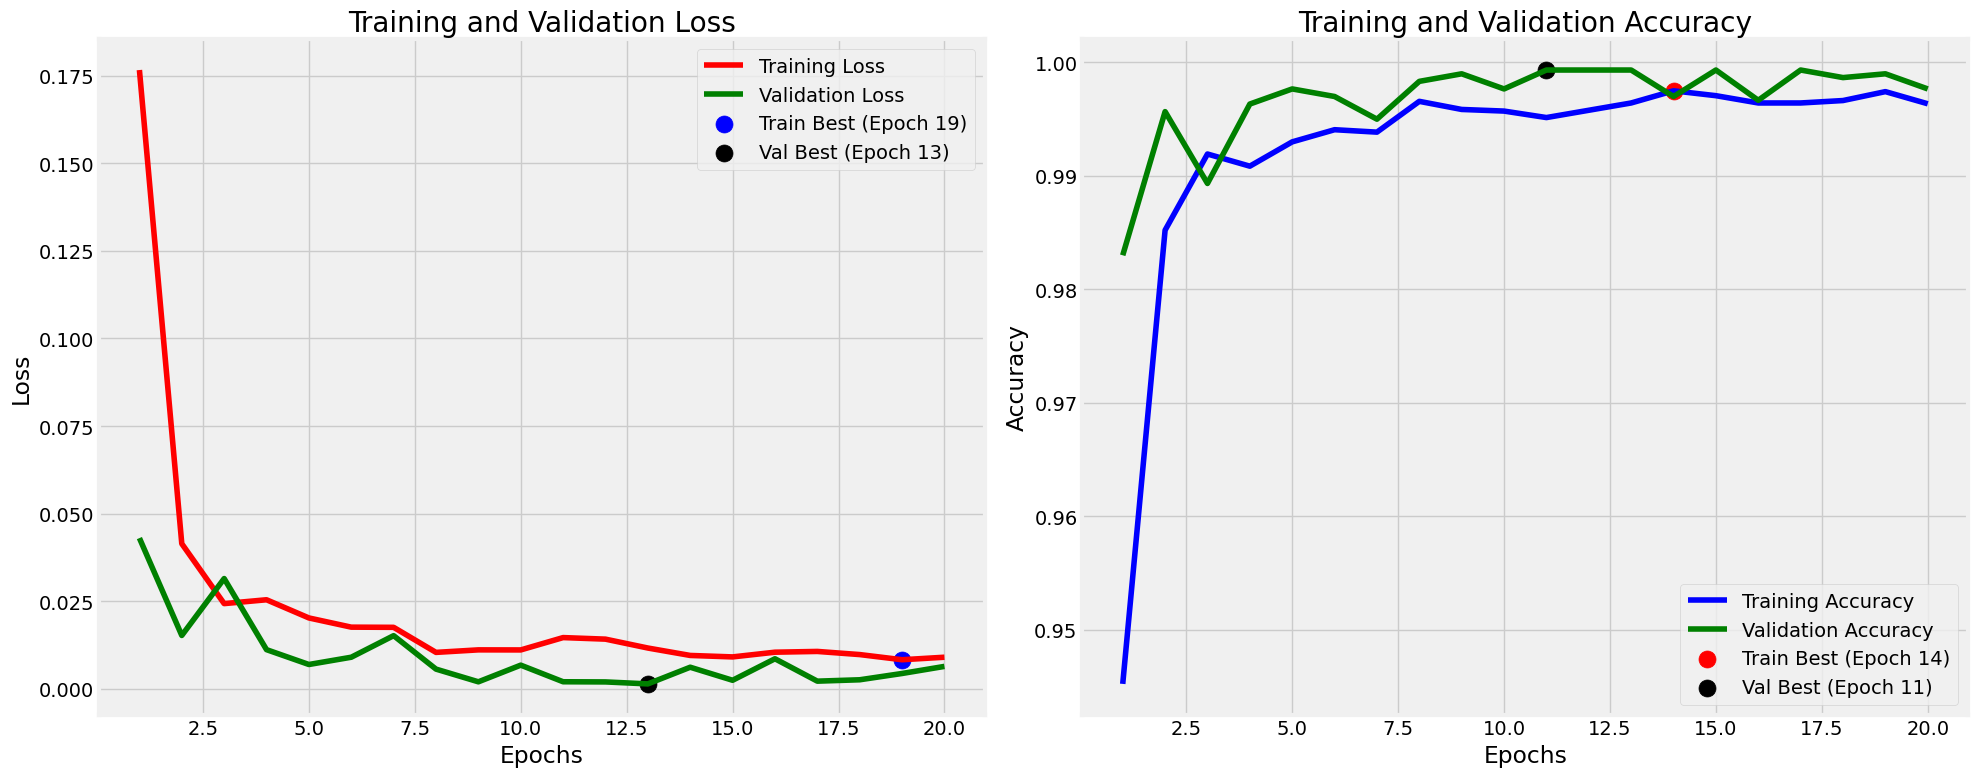

In [ ]:
# Ekstraksi data dari history
train_accuracy = history1.history['accuracy']
train_loss = history1.history['loss']
val_accuracy = history1.history['val_accuracy']
val_loss = history1.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Persiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Visualisasi Loss (Kerugian)
plt.subplot(1, 2, 1)
# Memplot garis Loss untuk data Training (warna merah 'r') dan Validation (warna hijau 'g')
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Menandai titik dengan Loss terendah menggunakan scatter plot (titik besar)
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)

# Memberi identitas pada grafik Loss
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Visualisasi Accuracy (Akurasi)
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Menandai titik dengan Akurasi tertinggi menggunakan scatter plot
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)

# Memberi identitas pada grafik Akurasi
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Menyesuaikan tata letak agar kedua grafik tidak saling tumpang tindih (rapi)
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = EfficientNetV2L_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 1 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

24/24 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step
Hyperparameter: 
Batch Size: 128
Learning Rate: 0.01
Epoch: 20

--- Informasi dari History 1 ---
Best Val Acc: 0.9993 (Epoch 11)
Testing Accuracy: 0.9993
Total Prediction Time: 68.10 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

  all_benign      0.997     1.000     0.999       750
   all_early      1.000     0.997     0.999       750
     all_pre      1.000     1.000     1.000       750
     all_pro      1.000     1.000     1.000       750

    accuracy                          0.999      3000
   macro avg      0.999     0.999     0.999      3000
weighted avg      0.999     0.999     0.999      3000




--- Confusion Matrix ---


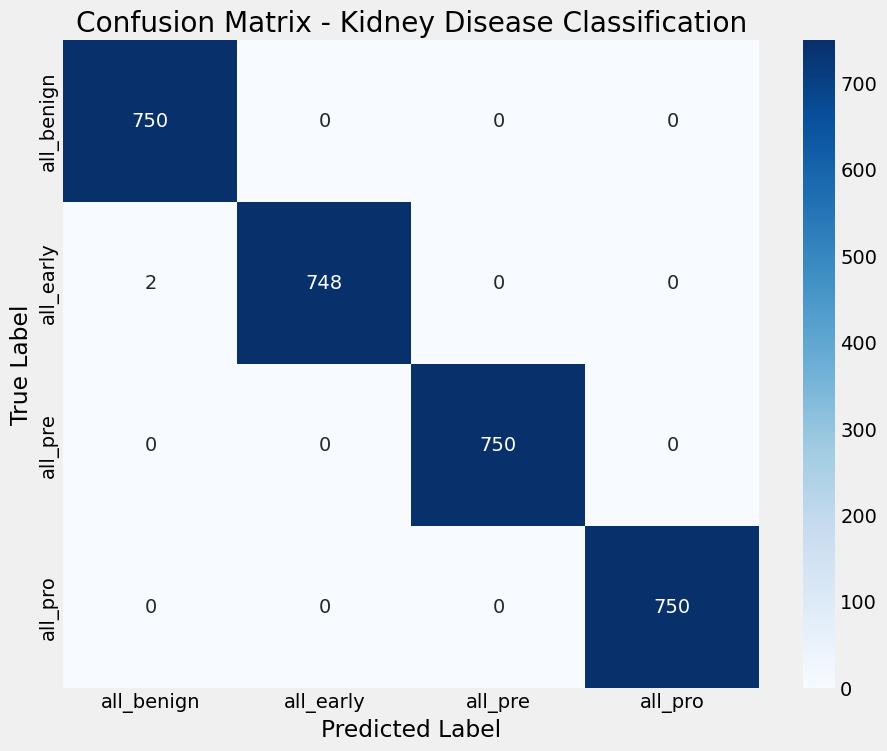

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 1 ---


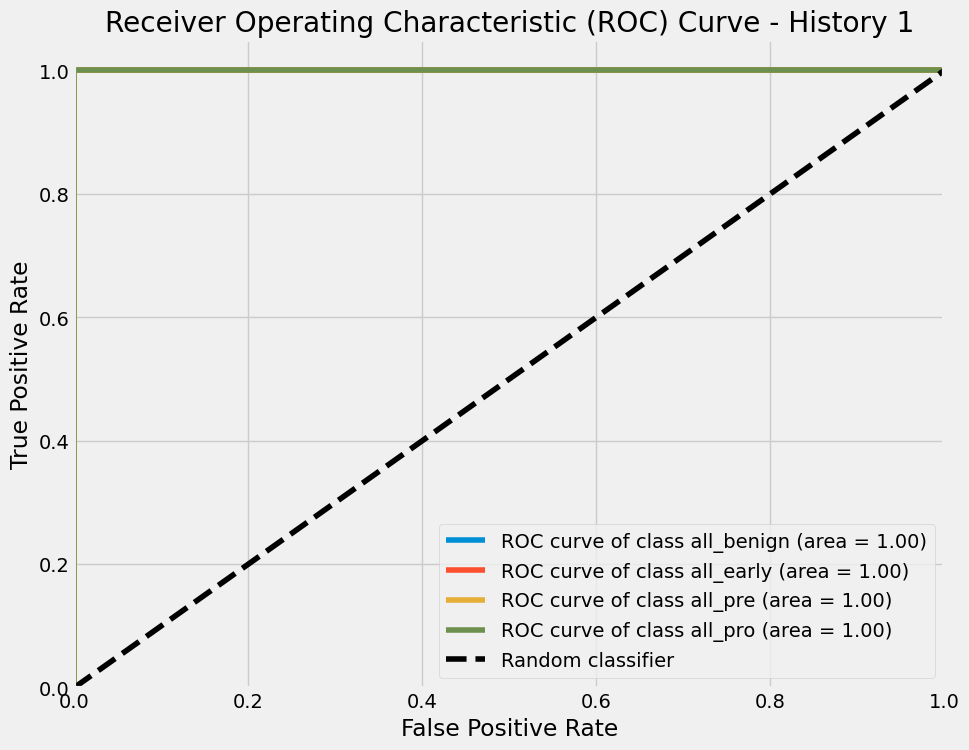

In [ ]:
print("\n--- ROC AUC for History 1 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
  # Get ROC curve for each class
  fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.show()

# Tuning Hyperparameter 2

In [ ]:
# --- Inisialisasi Parameter ---
# Learning rate mengontrol seberapa besar model mengubah bobotnya setiap kali belajar
learning_rate = 0.005
# Epochs adalah jumlah total pengulangan (iterasi) model mempelajari seluruh dataset
epochs = 20

# --- Konfigurasi Optimizer ---
# Menggunakan Adamax, variasi dari optimizer Adam yang lebih stabil untuk model besar
optimizer = Adamax(learning_rate=learning_rate)

# --- Kompilasi Model ---
# Menyiapkan model sebelum dilatih dengan menentukan :
EfficientNetV2L_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# --- Proses Pelatihan (Training) ---
# Melatih model menggunakan data dari train_generator
# Selama proses ini, model juga akan diuji secara berkala menggunakan validation data
# Hasilnya disimpan di variabel 'history' untuk dianalisis grafiknya nanti
history1 = EfficientNetV2L_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator,
  callbacks=callbacks)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8841 - loss: 0.4014
Epoch 1: val_accuracy improved from None to 0.99100, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 544s 4s/step - accuracy: 0.9484 - loss: 0.1671 - val_accuracy: 0.9910 - val_loss: 0.0252
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9866 - loss: 0.0400
Epoch 2: val_accuracy improved from 0.99100 to 0.99267, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 301s 3s/step - accuracy: 0.9881 - loss: 0.0356 - val_accuracy: 0.9927 - val_loss: 0.0235
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9914 - loss: 0.0225
Epoch 3: val_accuracy improved from 0.99267 to 0.99700, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - accuracy: 0.9919 - loss: 0.0227 - val_accurac

# Evaluation Metric 2

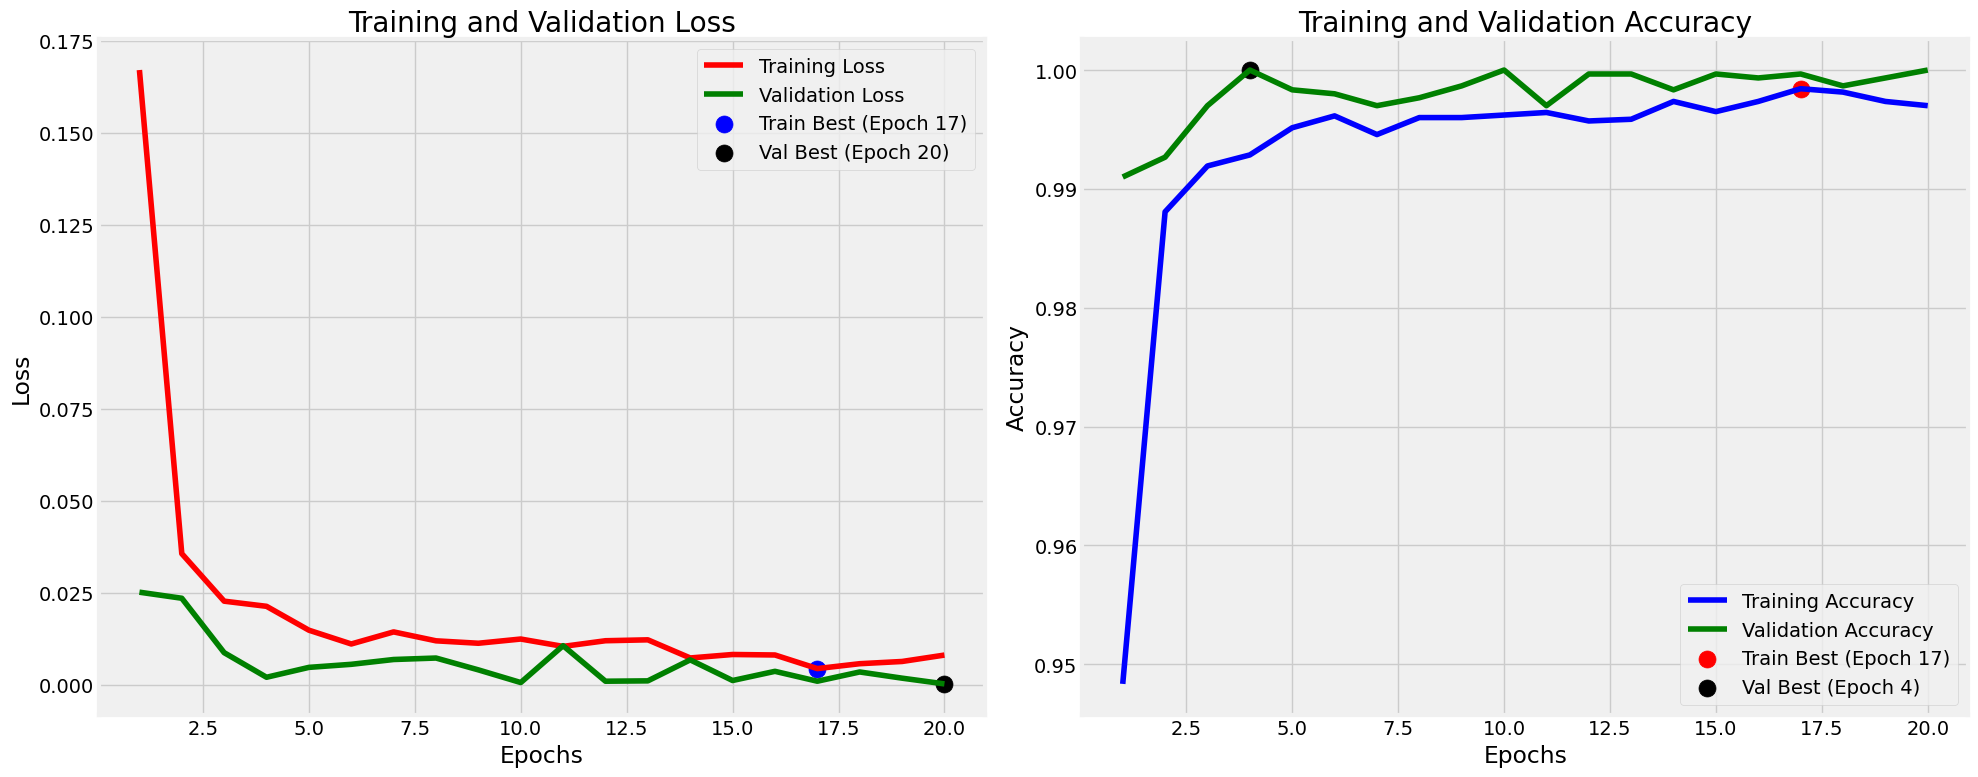

In [ ]:
# Ekstraksi data dari history
train_accuracy = history1.history['accuracy']
train_loss = history1.history['loss']
val_accuracy = history1.history['val_accuracy']
val_loss = history1.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Persiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Visualisasi Loss (Kerugian)
plt.subplot(1, 2, 1)
# Memplot garis Loss untuk data Training (warna merah 'r') dan Validation (warna hijau 'g')
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Menandai titik dengan Loss terendah menggunakan scatter plot (titik besar)
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)

# Memberi identitas pada grafik Loss
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Visualisasi Accuracy (Akurasi)
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Menandai titik dengan Akurasi tertinggi menggunakan scatter plot
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)

# Memberi identitas pada grafik Akurasi
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Menyesuaikan tata letak agar kedua grafik tidak saling tumpang tindih (rapi)
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = EfficientNetV2L_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 1 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

24/24 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step
Hyperparameter: 
Batch Size: 128
Learning Rate: 0.005
Epoch: 20

--- Informasi dari History 1 ---
Best Val Acc: 1.0000 (Epoch 4)
Testing Accuracy: 0.9997
Total Prediction Time: 69.04 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

  all_benign      0.999     1.000     0.999       750
   all_early      1.000     0.999     0.999       750
     all_pre      1.000     1.000     1.000       750
     all_pro      1.000     1.000     1.000       750

    accuracy                          1.000      3000
   macro avg      1.000     1.000     1.000      3000
weighted avg      1.000     1.000     1.000      3000




--- Confusion Matrix ---


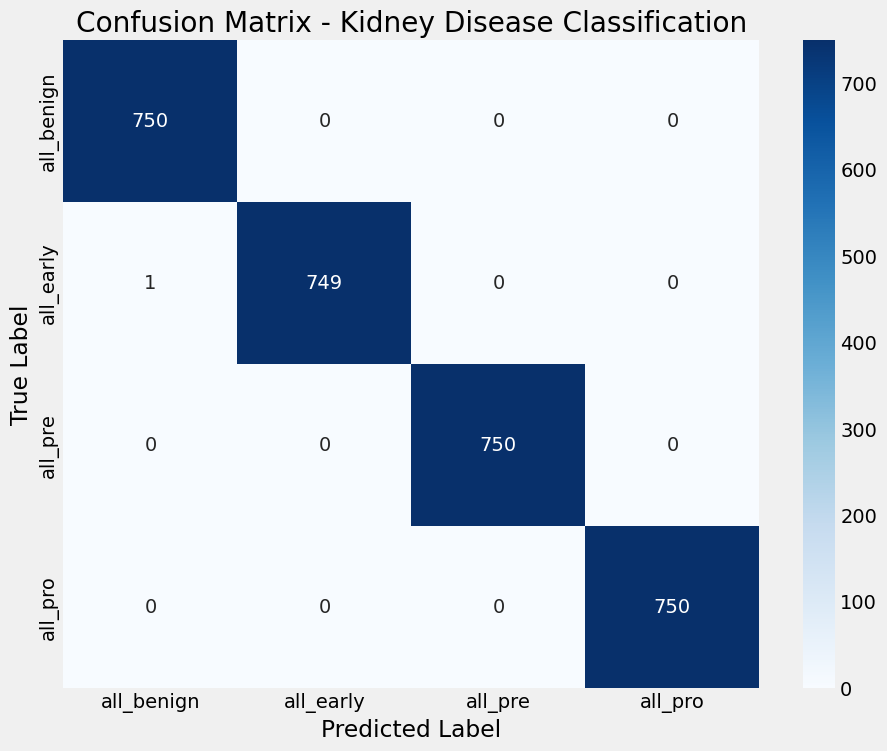

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Tuning Hyperparameter 3

In [ ]:
# --- Inisialisasi Parameter ---
# Learning rate mengontrol seberapa besar model mengubah bobotnya setiap kali belajar
learning_rate = 0.001
# Epochs adalah jumlah total pengulangan (iterasi) model mempelajari seluruh dataset
epochs = 20

# --- Konfigurasi Optimizer ---
# Menggunakan Adamax, variasi dari optimizer Adam yang lebih stabil untuk model besar
optimizer = Adamax(learning_rate=learning_rate)

# --- Kompilasi Model ---
# Menyiapkan model sebelum dilatih dengan menentukan :
EfficientNetV2L_model.compile(
  optimizer=optimizer,
  loss='categorical_crossentropy',
  metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)]

# --- Proses Pelatihan (Training) ---
# Melatih model menggunakan data dari train_generator
# Selama proses ini, model juga akan diuji secara berkala menggunakan validation data
# Hasilnya disimpan di variabel 'history' untuk dianalisis grafiknya nanti
history1 = EfficientNetV2L_model.fit(
  train_generator,
  epochs=epochs,
  validation_data=validation_generator,
  callbacks=callbacks)

Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8772 - loss: 0.3771
Epoch 1: val_accuracy improved from None to 0.96700, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 530s 4s/step - accuracy: 0.9431 - loss: 0.1694 - val_accuracy: 0.9670 - val_loss: 0.1184
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9818 - loss: 0.0507
Epoch 2: val_accuracy improved from 0.96700 to 0.99667, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 275s 2s/step - accuracy: 0.9864 - loss: 0.0416 - val_accuracy: 0.9967 - val_loss: 0.0208
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9928 - loss: 0.0235
Epoch 3: val_accuracy improved from 0.99667 to 0.99767, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 299s 3s/step - accuracy: 0.9921 - loss: 0.0242 - val_accurac

# Evaluation Metric 3

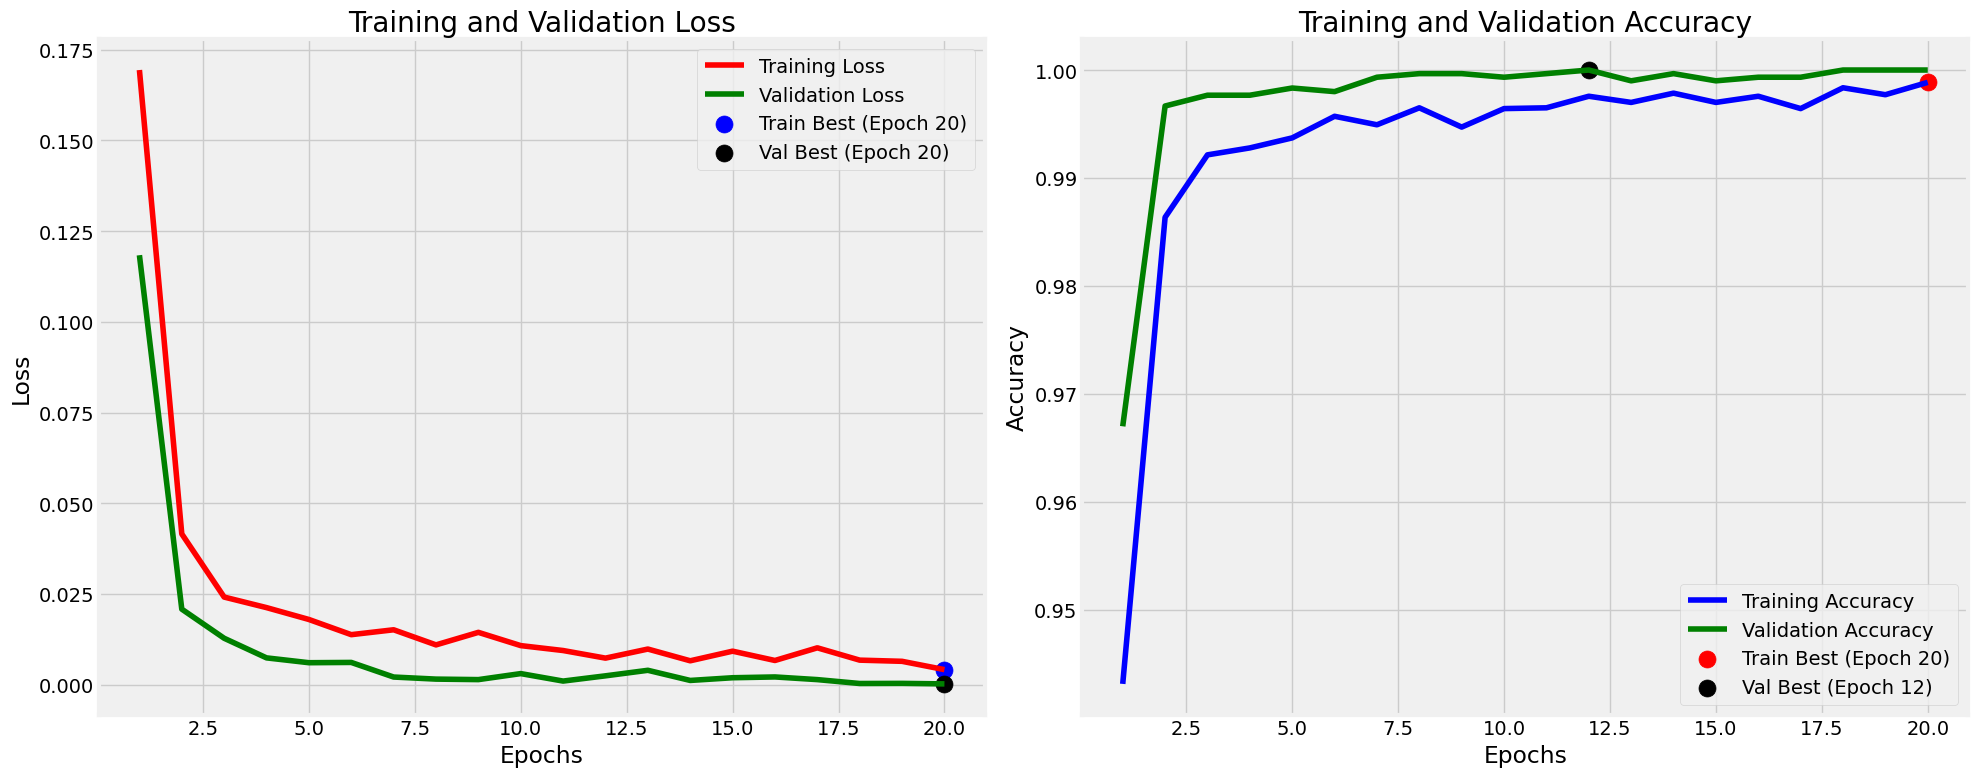

In [ ]:
# Ekstraksi data dari history
train_accuracy = history1.history['accuracy']
train_loss = history1.history['loss']
val_accuracy = history1.history['val_accuracy']
val_loss = history1.history['val_loss']

# Mencari indeks (epoch) di mana loss paling rendah
index_train_loss = np.argmin(train_loss)
train_loss_lowest = train_loss[index_train_loss]
index_val_loss = np.argmin(val_loss)
val_loss_lowest = val_loss[index_val_loss]

# Mencari indeks (epoch) di mana akurasi paling tinggi
index_train_accuracy = np.argmax(train_accuracy)
train_accuracy_highest = train_accuracy[index_train_accuracy]
index_val_accuracy = np.argmax(val_accuracy)
val_accuracy_highest = val_accuracy[index_val_accuracy]

# Persiapan Label dan Sumbu X
Epochs = [i+1 for i in range(len(train_accuracy))]
train_loss_label = f"Train Best (Epoch {index_train_loss+1})"
val_loss_label = f"Val Best (Epoch {index_val_loss+1})"
val_accuracy_label = f"Val Best (Epoch {index_val_accuracy+1})"
train_accuracy_label = f"Train Best (Epoch {index_train_accuracy+1})"

# Visualisasi
plt.figure(figsize=(20, 8))
plt.style.use('fivethirtyeight')

# Visualisasi Loss (Kerugian)
plt.subplot(1, 2, 1)
# Memplot garis Loss untuk data Training (warna merah 'r') dan Validation (warna hijau 'g')
plt.plot(Epochs, train_loss, 'r', label='Training Loss')
plt.plot(Epochs, val_loss, 'g', label='Validation Loss')

# Menandai titik dengan Loss terendah menggunakan scatter plot (titik besar)
plt.scatter(index_train_loss+1, train_loss_lowest, s=150, c='blue', label=train_loss_label)
plt.scatter(index_val_loss+1, val_loss_lowest, s=150, c='black', label=val_loss_label)

# Memberi identitas pada grafik Loss
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Visualisasi Accuracy (Akurasi)
plt.subplot(1, 2, 2)
plt.plot(Epochs, train_accuracy, 'b', label='Training Accuracy') # Added training accuracy plot
plt.plot(Epochs, val_accuracy, 'g', label='Validation Accuracy')

# Menandai titik dengan Akurasi tertinggi menggunakan scatter plot
plt.scatter(index_train_accuracy + 1, train_accuracy_highest, s=150, c='red', label=train_accuracy_label) # Added best train accuracy point
plt.scatter(index_val_accuracy + 1, val_accuracy_highest, s=150, c='black', label=val_accuracy_label)

# Memberi identitas pada grafik Akurasi
plt.title('Training and Validation Accuracy') # Updated title
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Menyesuaikan tata letak agar kedua grafik tidak saling tumpang tindih (rapi)
plt.tight_layout()
plt.show()

In [ ]:
# Mengembalikan pointer atau indeks data testing ke urutan pertama
test_generator.reset()
# Mengambil waktu saat ini (dalam detik) sebelum model mulai bekerja
start_time = time.time()
# Model mengambil data dari test_generator dan memberikan prediksi
Y_pred = EfficientNetV2L_model.predict(test_generator)
# Mencatat waktu tepat setelah model selesai melakukan prediksi terhadap seluruh data
end_time = time.time()
# Menghitung selisih waktu
inference_time = end_time - start_time
# Mengambil indeks dengan nilai tertinggi
y_pred = np.argmax(Y_pred, axis=1)
# Mengambil label asli yang benar dari testing untuk dibandingkan
y_true = test_generator.classes
# Menghitung persentase kecocokan antara jawaban model dan jawaban asli
test_accuracy = accuracy_score(y_true, y_pred)

print(f"Hyperparameter: ")
print(f"Batch Size: {batch_size}")
print(f"Learning Rate: {learning_rate}")
print(f"Epoch: {epochs}")

print(f"\n--- Informasi dari History 1 ---")
print(f"Best Val Acc: {max(val_accuracy):.4f} (Epoch {np.argmax(val_accuracy) + 1})")
print(f"Testing Accuracy: {test_accuracy:.4f}")
print(f"Total Prediction Time: {inference_time:.2f} seconds")

24/24 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step
Hyperparameter: 
Batch Size: 128
Learning Rate: 0.001
Epoch: 20

--- Informasi dari History 1 ---
Best Val Acc: 1.0000 (Epoch 12)
Testing Accuracy: 1.0000
Total Prediction Time: 64.78 seconds


In [ ]:
# Menampilkan evaluasi performa model klasifikasi secara detail dalam bentuk classification report
print("\n--- Classification Report ---")
class_labels = list(train_generator.class_indices.keys())
cls_report = classification_report(y_true, y_pred, target_names=class_labels, digits=3)
print(cls_report)


--- Classification Report ---
              precision    recall  f1-score   support

  all_benign      1.000     1.000     1.000       750
   all_early      1.000     1.000     1.000       750
     all_pre      1.000     1.000     1.000       750
     all_pro      1.000     1.000     1.000       750

    accuracy                          1.000      3000
   macro avg      1.000     1.000     1.000      3000
weighted avg      1.000     1.000     1.000      3000




--- Confusion Matrix ---


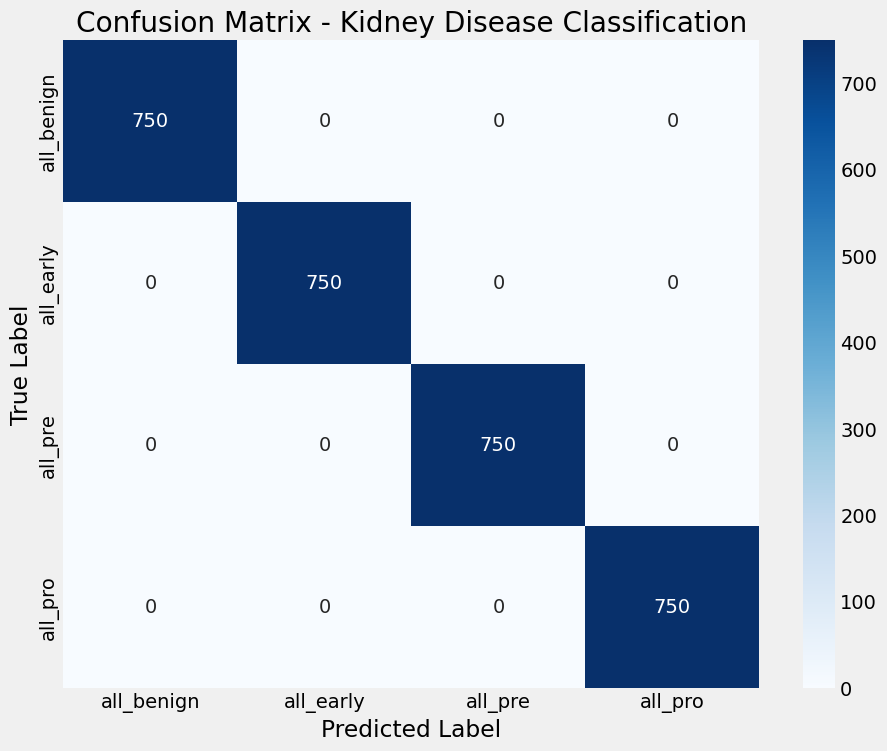

In [ ]:
# Membuat dan menampilkan Confusion Matrix dalam bentuk visual (heatmap)
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Kidney Disease Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


--- ROC AUC for History 1 ---


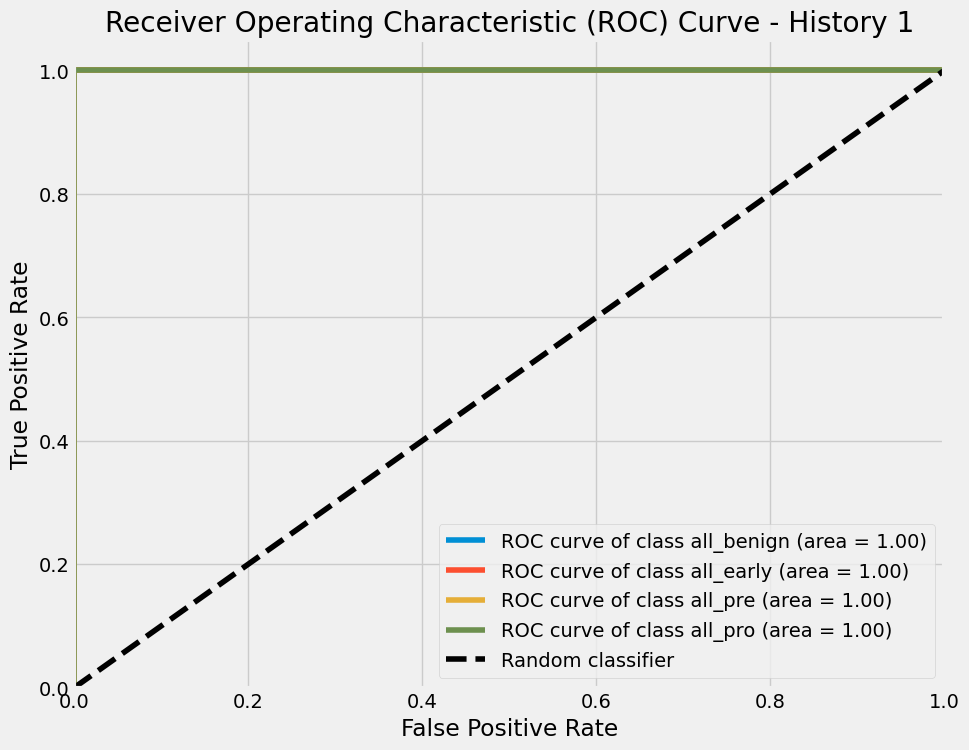

In [ ]:
print("\n--- ROC AUC for History 1 ---")

# One-hot encode y_true for multi-class ROC AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_labels))

plt.figure(figsize=(10, 8))
for i in range(len(class_labels)):
  # Get ROC curve for each class
  fpr, tpr, _ = roc_curve(y_true_one_hot[:, i], Y_pred[:, i])
  roc_auc = auc(fpr, tpr)

  # Plot ROC curve
  plt.plot(fpr, tpr, label=f'ROC curve of class {class_labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - History 1')
plt.legend(loc="lower right")
plt.show()

# Prediction on New Image

In [ ]:
# --- 1. Persiapan Model ---
EfficientNetV2L_model.save("Classification_of_Acute_Lymphoblastic_Leukemia.keras")
# Memuat model yang sudah dilatih dari file .keras
loaded_model = tf.keras.models.load_model("/content/Classification_of_Acute_Lymphoblastic_Leukemia.keras", compile=True)
# Mengompilasi ulang model untuk memastikan optimizer dan fungsi loss siap digunakan
loaded_model.compile(Adamax(learning_rate=0.01), loss='categorical_crossentropy', metrics=['accuracy'])

# Fungsi Utama untuk Visualisasi Grad-CAM
def visualize_grad_cam(model, image_path, class_labels):

  image = Image.open(image_path).convert('RGB') # Convert image to RGB

  # --- 2. Preprocessing (Penyesuaian Gambar) ---
  # Mengubah ukuran gambar ke 224x224 (standar MobileNetV3)
  img = image.resize((224, 224))
  img_array = tf.keras.preprocessing.image.img_to_array(img)
  original_img = img_array.copy()
  img_array = tf.expand_dims(img_array, 0)

  # Apply the custom preprocessing function with CLAHE
  preprocessed_img_array = preprocess_input(img_array)

  # --- 3. Inferensi / Prediksi
  # Meminta model menebak gambar
  predictions = model.predict(preprocessed_img_array)
  predicted_class_idx = np.argmax(predictions)
  predicted_class = class_labels[predicted_class_idx]
  confidence = 100 * np.max(predictions)

  # Menampilkan log hasil prediksi di konsol
  print(f"Image path: {image_path}")
  print(f"Predicted class: {predicted_class}")
  print(f"Confidence: {confidence:.2f}%")
  print("\nAll class probabilities:")
  for i, prob in enumerate(predictions[0]):
    print(f"{class_labels[i]}: {100 * prob:.2f}%")

  # --- 4. Persiapan Struktur GRAD-CAM (Pembedahan Model) ---
  # Mengambil 'backbone' model (MobileNetV3Large) yang ada di layer pertama
  base_model_feature_extractor = model.layers[0]
  # Mengambil output dari layer konvolusi terakhir sebagai peta fitur (feature map)
  feature_map_output_tensor = base_model_feature_extractor.output

  # Membuat model sub-bagian untuk mengekstrak fitur visual
  feature_map_model = tf.keras.Model(
    inputs = base_model_feature_extractor.input,
    outputs = feature_map_output_tensor)

  # Menyiapkan input untuk bagian klasifikasi (biasanya berukuran 7x7x960)
  classifier_input_shape = feature_map_output_tensor.shape[1:]
  classifier_input = tf.keras.Input(shape=classifier_input_shape)

  # Menyambungkan kembali lapisan klasifikasi (Dense/Pooling) ke input baru
  x = classifier_input
  for layer in model.layers[1:]:
    x = layer(x)
  classifier_model = tf.keras.Model(inputs=classifier_input, outputs=x)

  # --- 5. Perhitungan Gradien (Mencari Bagian Penting) ---
  # Menggunakan GradientTape untuk merekam operasi matematis demi mendapatkan gradien
  with tf.GradientTape() as tape:
    # 1. Dapatkan peta fitur dari gambar
    feature_map_output = feature_map_model(preprocessed_img_array)
    tape.watch(feature_map_output) # Pantau perubahan pada peta fitur ini

    # 2. Masukkan ke klasifikasi untuk dapat prediksi akhir
    predictions_from_classifier = classifier_model(feature_map_output)
    class_channel = predictions_from_classifier[:, predicted_class_idx]

  # Hitung seberapa sensitif skor prediksi terhadap setiap pixel di peta fitur
  grads = tape.gradient(class_channel, feature_map_output)
  # Ambil rata-rata gradien (Global Average Pooling) untuk menentukan bobot tiap channel
  pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

  # --- 6. Pembuatan Heatmap (Peta Panas) ---
  # Kalikan peta fitur dengan bobot gradien untuk melihat area mana yang paling "berpengaruh"
  last_conv_layer_output_for_heatmap = feature_map_output[0]
  heatmap = last_conv_layer_output_for_heatmap @ pooled_grads[..., tf.newaxis]
  heatmap = tf.squeeze(heatmap) # Hilangkan dimensi yang tidak perlu

  # Normalisasi: Ubah nilai heatmap agar berada di rentang 0 sampai 1 (ReLu + Max)
  heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
  heatmap = heatmap.numpy()

  # --- 7. VISUALISASI AKHIR (Pengaggabungan)
  # Resize heatmap agar ukurannya sama dengan gambar asli (224 x 224)
  original_img_uint8 = np.uint8(original_img)
  heatmap = cv2.resize(heatmap, (original_img_uint8.shape[1], original_img_uint8.shape[0]))
  heatmap = np.uint8(255 * heatmap)
  # Beri warna pada heatmap (Biru = Dingin/Biasa, Merah = Panas/Penting)
  heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET) # Ubah ke skala 0-255

  # Timpa heatmap ke gambar asli dengan transparansi (40% heatmap)
  superimposed_img = heatmap * 0.4 + original_img_uint8
  superimposed_img = np.uint8(255 * (superimposed_img / np.max(superimposed_img)))

  # Tampilkan hasil secara berdampingan: Gambar Asli vs Lokasi Deteksi AI
  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.imshow(img);
  plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(superimposed_img)
  plt.title(f"Grad-CAM for {predicted_class}")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

  return predicted_class, confidence, superimposed_img

1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step
Image path: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/ALL/all_benign/all_benign_0001.jpg
Predicted class: all_benign
Confidence: 100.00%

All class probabilities:
all_benign: 100.00%
all_early: 0.00%
all_pre: 0.00%
all_pro: 0.00%


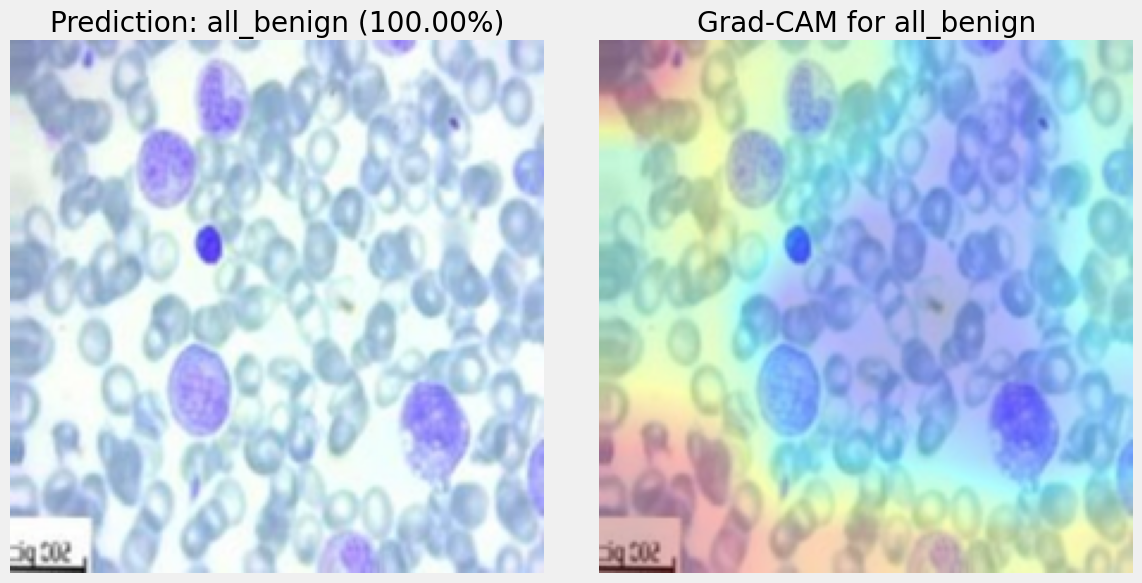

In [ ]:
# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Multi Cancer/ALL/all_benign", "all_benign_0001.jpg")
class_labels_for_test = ["all_benign", "all_early", "all_pre", "all_pro"]
# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Image path: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/ALL/all_early/all_early_0001.jpg
Predicted class: all_early
Confidence: 100.00%

All class probabilities:
all_benign: 0.00%
all_early: 100.00%
all_pre: 0.00%
all_pro: 0.00%


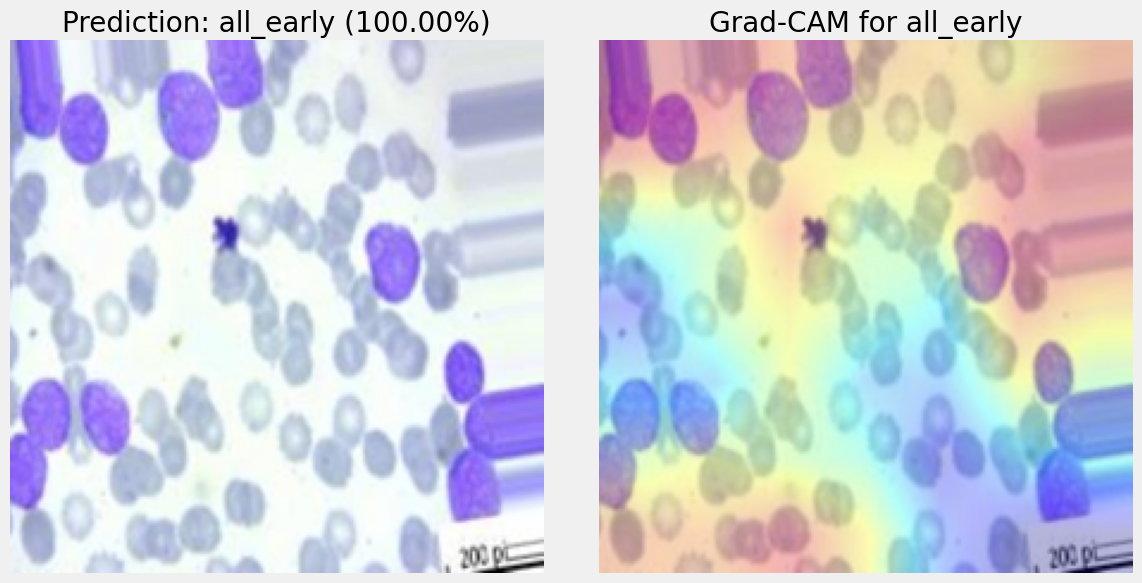

In [ ]:
# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Multi Cancer/ALL/all_early", "all_early_0001.jpg")
class_labels_for_test = ["all_benign", "all_early", "all_pre", "all_pro"]
# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Image path: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/ALL/all_pre/all_pre_0001.jpg
Predicted class: all_pre
Confidence: 100.00%

All class probabilities:
all_benign: 0.00%
all_early: 0.00%
all_pre: 100.00%
all_pro: 0.00%


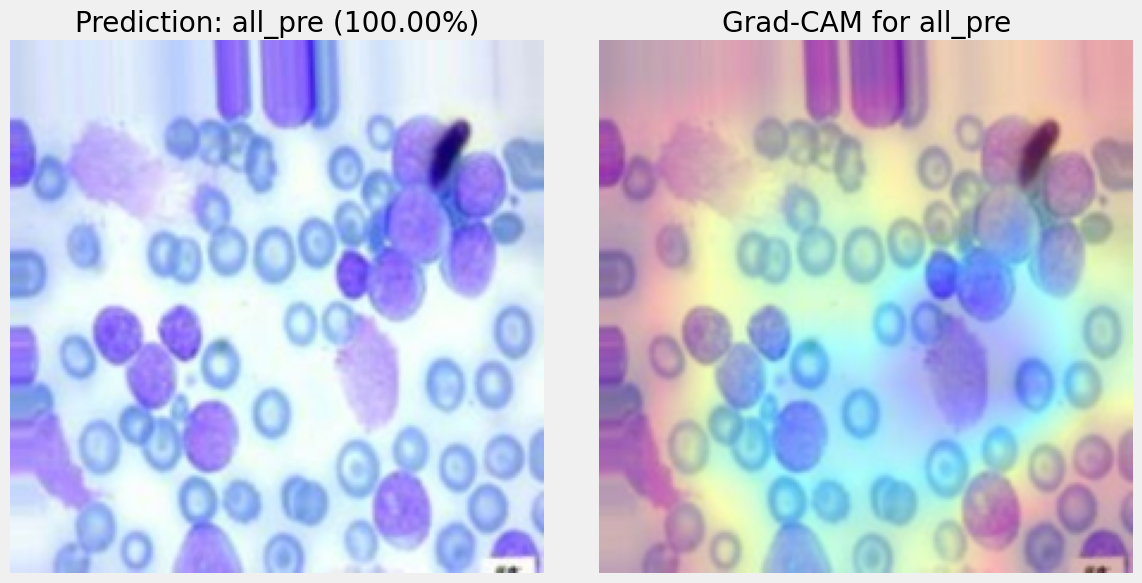

In [ ]:
# Define the image path and class labels
image_path_for_test = os.path.join(parent_dir, "Multi Cancer/ALL/all_pre", "all_pre_0001.jpg")
class_labels_for_test = ["all_benign", "all_early", "all_pre", "all_pro"]
# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Image path: /root/.cache/kagglehub/datasets/obulisainaren/multi-cancer/versions/3/Multi Cancer/Multi Cancer/ALL/all_pro/all_pro_0001.jpg
Predicted class: all_pro
Confidence: 100.00%

All class probabilities:
all_benign: 0.00%
all_early: 0.00%
all_pre: 0.00%
all_pro: 100.00%


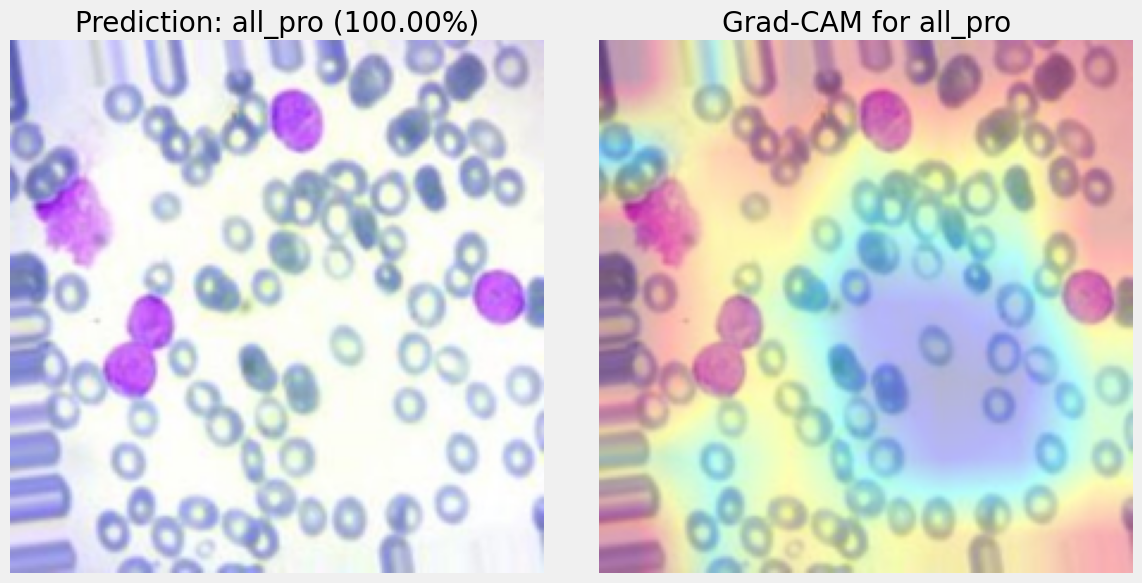

In [ ]:
image_path_for_test = os.path.join(parent_dir, "Multi Cancer/ALL/all_pro", "all_pro_0001.jpg")
class_labels_for_test = ["all_benign", "all_early", "all_pre", "all_pro"]
# Call the function
predicted_class, confidence, grad_cam_image = visualize_grad_cam(loaded_model, image_path_for_test, class_labels_for_test)